In [311]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [312]:
df = pd.read_csv('./archive/heart_disease_uci.csv')

df.head()

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


In [313]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    object 
 3   dataset   920 non-null    object 
 4   cp        920 non-null    object 
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    object 
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    object 
 13  ca        309 non-null    float64
 14  thal      434 non-null    object 
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(8)
memory usage: 115.1+ KB


In [314]:
df.describe()

,id,age,trestbps,chol,thalch,oldpeak,ca,num
count,920.000000,920.000000,861.000000,890.000000,865.000000,858.000000,309.000000,920.000000
mean,460.500000,53.510870,132.132404,199.130337,137.545665,0.878788,0.676375,0.995652
std,265.725422,9.424685,19.066070,110.780810,25.926276,1.091226,0.935653,1.142693
min,1.000000,28.000000,0.000000,0.000000,60.000000,-2.600000,0.000000,0.000000
25%,230.750000,47.000000,120.000000,175.000000,120.000000,0.000000,0.000000,0.000000
50%,460.500000,54.000000,130.000000,223.000000,140.000000,0.500000,0.000000,1.000000
75%,690.250000,60.000000,140.000000,268.000000,157.000000,1.500000,1.000000,2.000000
max,920.000000,77.000000,200.000000,603.000000,202.000000,6.200000,3.000000,4.000000


In [315]:
df.shape

(920, 16)

In [316]:
df = df.drop(columns=["id", "ca", "thal", "dataset", "slope"])

In [317]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,num
0,63,Male,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,0
1,67,Male,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,2
2,67,Male,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,1
3,37,Male,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,0
4,41,Female,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,0


### Feature selection

In [318]:
df.corr(numeric_only=True)["num"].sort_values(ascending=False)

num         1.000000
oldpeak     0.443084
age         0.339596
trestbps    0.122291
chol       -0.231547
thalch     -0.366265
Name: num, dtype: float64

#### columns unique values

In [319]:
unique_counts = df.nunique()
print(unique_counts)


age          50
sex           2
cp            4
trestbps     61
chol        217
fbs           2
restecg       3
thalch      119
exang         2
oldpeak      53
num           5
dtype: int64


#### missing values

In [320]:
missing_value = df.isnull().sum()
print(missing_value)

age          0
sex          0
cp           0
trestbps    59
chol        30
fbs         90
restecg      2
thalch      55
exang       55
oldpeak     62
num          0
dtype: int64


In [321]:
class_counts = df["num"].value_counts()
print(class_counts)


num
0    411
1    265
2    109
3    107
4     28
Name: count, dtype: int64


In [322]:
df["num"] = (df["num"] > 0).astype(int)

In [323]:
df["num"].value_counts()

num
1    509
0    411
Name: count, dtype: int64

#### Filling missing values


In [324]:
fill_with_mean_column = ["trestbps", "chol", "thalch", "oldpeak"]

df[fill_with_mean_column] = df[fill_with_mean_column].fillna(df[fill_with_mean_column].mean())

fill_with_mode_column = ["fbs", "restecg", "exang"]

for col in fill_with_mode_column:
    df[col] = df[col].fillna(df[col].mode()[0])

C:\Users\rifat\AppData\Local\Temp\ipykernel_18100\3772511149.py:8: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[col] = df[col].fillna(df[col].mode()[0])


In [325]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,num
0,63,Male,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,0
1,67,Male,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,1
2,67,Male,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,1
3,37,Male,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,0
4,41,Female,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,0


In [326]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 11 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       920 non-null    int64  
 1   sex       920 non-null    object 
 2   cp        920 non-null    object 
 3   trestbps  920 non-null    float64
 4   chol      920 non-null    float64
 5   fbs       920 non-null    bool   
 6   restecg   920 non-null    object 
 7   thalch    920 non-null    float64
 8   exang     920 non-null    bool   
 9   oldpeak   920 non-null    float64
 10  num       920 non-null    int32  
dtypes: bool(2), float64(4), int32(1), int64(1), object(3)
memory usage: 63.0+ KB


In [327]:
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalch      0
exang       0
oldpeak     0
num         0
dtype: int64

In [328]:
df["sex"].value_counts()

sex
Male      726
Female    194
Name: count, dtype: int64

In [329]:
df['sex'] = df["sex"].map({
    'Male': 1,
    'Female': 2
})

In [330]:
df = pd.get_dummies(df, columns=["cp"], drop_first=True)
df = pd.get_dummies(df, columns=["restecg"], drop_first=True)

In [331]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 14 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       920 non-null    int64  
 1   sex                       920 non-null    int64  
 2   trestbps                  920 non-null    float64
 3   chol                      920 non-null    float64
 4   fbs                       920 non-null    bool   
 5   thalch                    920 non-null    float64
 6   exang                     920 non-null    bool   
 7   oldpeak                   920 non-null    float64
 8   num                       920 non-null    int32  
 9   cp_atypical angina        920 non-null    bool   
 10  cp_non-anginal            920 non-null    bool   
 11  cp_typical angina         920 non-null    bool   
 12  restecg_normal            920 non-null    bool   
 13  restecg_st-t abnormality  920 non-null    bool   
dtypes: bool(7)

In [332]:
df.head()

,age,sex,trestbps,chol,fbs,thalch,exang,oldpeak,num,cp_atypical angina,cp_non-anginal,cp_typical angina,restecg_normal,restecg_st-t abnormality
0,63,1,145.0,233.0,True,150.0,False,2.3,0,False,False,True,False,False
1,67,1,160.0,286.0,False,108.0,True,1.5,1,False,False,False,False,False
2,67,1,120.0,229.0,False,129.0,True,2.6,1,False,False,False,False,False
3,37,1,130.0,250.0,False,187.0,False,3.5,0,False,True,False,True,False
4,41,2,130.0,204.0,False,172.0,False,1.4,0,True,False,False,False,False


### Split for training phase

In [333]:
X = df.drop("num", axis=1)
y = df["num"]

In [334]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state = 42)

In [335]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [336]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_curve, roc_auc_score, f1_score

models = {
    "Logistic Regression": LogisticRegression(random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "XGBoost": XGBClassifier(random_state=42, eval_metric="logloss")
}

In [337]:
y_preds = {}
y_preds_probas = {}
fprs = {}
tprs = {}
roc_scores = {}
results = []

for model_name, model in models.items():

    model.fit(X_train, y_train)
    y_preds[model_name] = model.predict(X_test)
    y_preds_probas[model_name] = model.predict_proba(X_test)[:, 1]
    roc_scores[model_name] = roc_auc_score(y_test, y_preds_probas[model_name])
    
    fprs[model_name], tprs[model_name], _ = roc_curve(
    y_test,
    y_preds_probas[model_name]
    )

    results.append({
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, y_preds[model_name]),
        "Precision": precision_score(y_test, y_preds[model_name]),
        "Recall": recall_score(y_test, y_preds[model_name]),
        "F1 Score": f1_score(y_test, y_preds[model_name]),
        "ROC AUC": roc_auc_score(y_test, y_preds_probas[model_name]),
    })
    

### Evaluation Phase

In [338]:

for model_name, y_pred in y_preds.items():
    print(f'Model: {model_name}')
    print(f'accuracy is = {accuracy_score(y_test, y_pred)}')
    print(f'f1 score is = {f1_score(y_test, y_pred)}')
    print(f'roc_auc_score is = {roc_auc_score(y_test, y_pred)}')
    print("="*40)

Model: Logistic Regression
accuracy is = 0.8043478260869565
f1 score is = 0.8301886792452831
roc_auc_score is = 0.8036697247706422
Model: Decision Tree
accuracy is = 0.7554347826086957
f1 score is = 0.7783251231527094
roc_auc_score is = 0.7623853211009175
Model: Random Forest
accuracy is = 0.8532608695652174
f1 score is = 0.8755760368663594
roc_auc_score is = 0.8491131498470949
Model: XGBoost
accuracy is = 0.8369565217391305
f1 score is = 0.8571428571428571
roc_auc_score is = 0.8395107033639142


# Model Comparison

In [339]:
comparison = pd.DataFrame(results)
comparison

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Logistic Regression,0.804348,0.854369,0.807339,0.830189,0.889541
1,Decision Tree,0.755435,0.840426,0.724771,0.778325,0.762385
2,Random Forest,0.853261,0.879630,0.871560,0.875576,0.909541
3,XGBoost,0.836957,0.891089,0.825688,0.857143,0.896269


### ROC curve

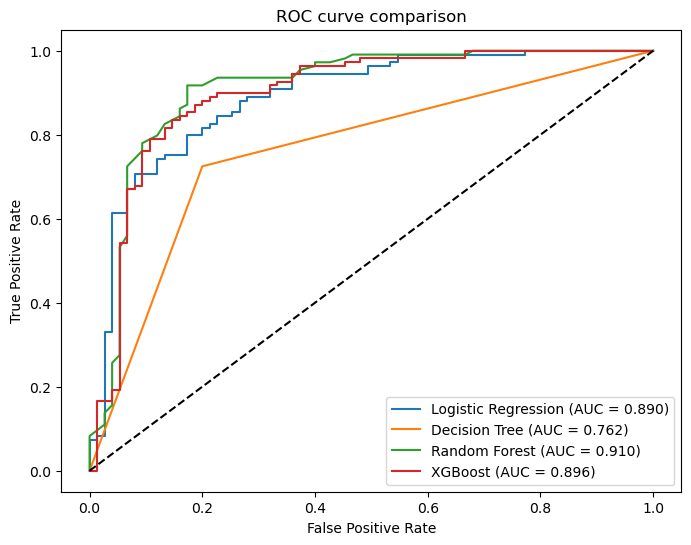

In [342]:


plt.figure(figsize=(8,6))

for model_name in models:

    plt.plot(
        fprs[model_name],
        tprs[model_name],
        label=f"{model_name} (AUC = {roc_scores[model_name]:.3f})"
    )

plt.plot([0,1], [0,1], 'k--')

plt.title("ROC curve comparison")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.legend()

plt.show()

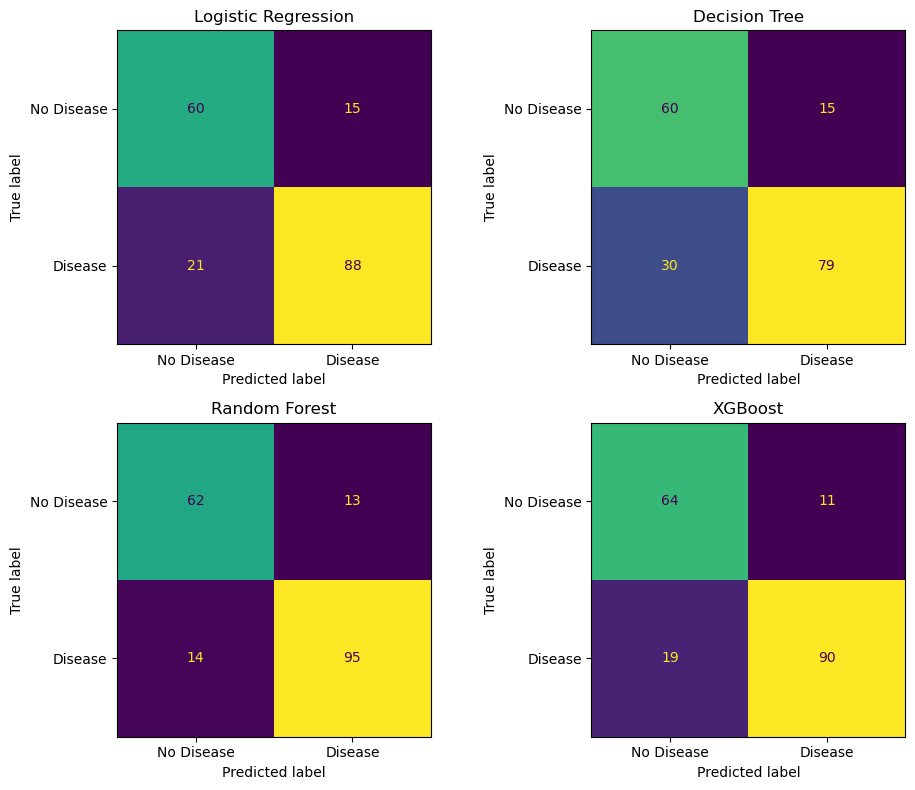

In [343]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.ravel()

for i, (model_name, y_pred) in enumerate(y_preds.items()):

    cm = confusion_matrix(y_test, y_pred)

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["No Disease", "Disease"]
    )

    disp.plot(ax=axes[i], colorbar=False)

    axes[i].set_title(model_name)

plt.tight_layout()
plt.show()